
# Arima Model


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
path = '/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/monthly_counts/'

all_files = glob.glob(os.path.join(path, '*.csv'))
if len(all_files) == 0:
    raise FileNotFoundError(f'No CSV files found in: {path}\nCheck the folder path in Google Drive.')

df_list = [pd.read_csv(f) for f in all_files]
monthly_rides = pd.concat(df_list, ignore_index=True)

if "Unnamed: 0" in monthly_rides.columns:
    monthly_rides = monthly_rides.drop(columns=["Unnamed: 0"])

monthly_rides["month"] = pd.to_datetime(monthly_rides["month"])
monthly_rides = monthly_rides.sort_values("month")


# build monthly time series
ts = monthly_rides.set_index("month")["num_trips"].asfreq("MS").ffill()

# exclude anomalous row (e.g., incomplete month) if present
ts = ts.loc[ts.index != pd.Timestamp('2026-01-01')]

ts.head()


,num_trips
month,
2013-01-01,1590062
2013-02-01,1800402
2013-03-01,2261377
2013-04-01,2116671
2013-05-01,2260977


In [ ]:

h = 12
train, test = ts.iloc[:-h], ts.iloc[-h:]

print("Train range:", train.index.min(), "to", train.index.max(), "| n =", len(train))
print("Test  range:", test.index.min(),  "to", test.index.max(),  "| n =", len(test))


Train range: 2013-01-01 00:00:00 to 2024-12-01 00:00:00 | n = 144
Test  range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00 | n = 12


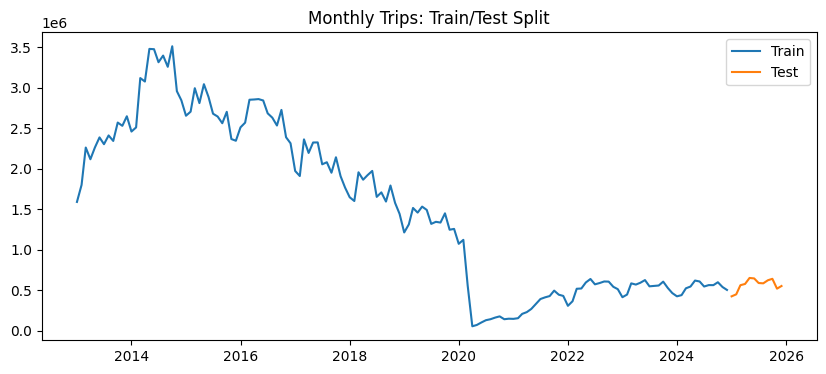

In [ ]:

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.legend()
plt.title("Monthly Trips: Train/Test Split")
plt.show()



## Fit ARIMA



In [ ]:
order = (1, 1, 1)
model = ARIMA(train, order=order)
results = model.fit()

print("ARIMA order:", results.model.order)


ARIMA order: (1, 1, 1)


In [ ]:

txt = results.summary().as_text()
txt = txt.replace("SARIMAX Results", "ARIMA Results", 1)
print(txt)


                               ARIMA Results                                
Dep. Variable:              num_trips   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1923.305
Date:                Thu, 26 Feb 2026   AIC                           3852.609
Time:                        07:51:56   BIC                           3861.498
Sample:                    01-01-2013   HQIC                          3856.221
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5182      0.519     -0.998      0.318      -1.536       0.499
ma.L1          0.4619      0.543      0.851      0.395      -0.602       1.526
sigma2      2.651e+10   1.67e-11   1.59e+21      0.000

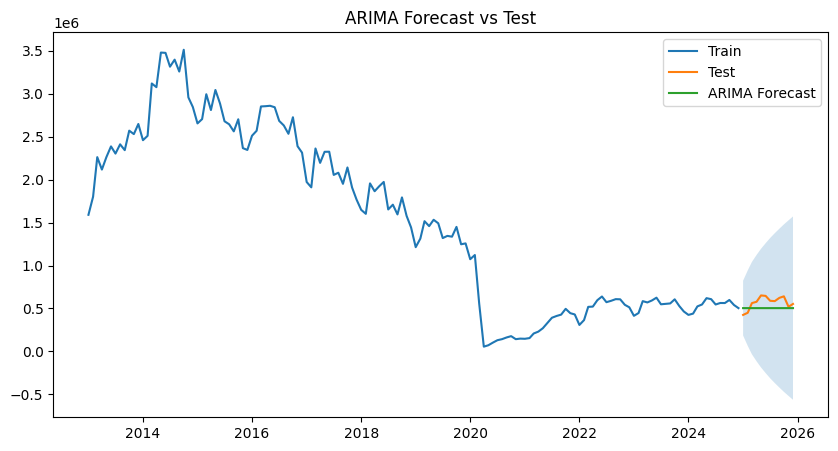

In [ ]:

# ---------- Forecast on test set ----------
fc = results.get_forecast(steps=len(test))
pred = fc.predicted_mean
conf_int = fc.conf_int()

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, pred, label="ARIMA Forecast")
plt.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("ARIMA Forecast vs Test")
plt.show()


In [ ]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    # avoid divide-by-zero
    denom = np.where(denom == 0, 1e-8, denom)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)

def mase(y_true, y_pred, train_series, m=12):
    # seasonal naive scale (m=12 for monthly)
    train_series = np.asarray(train_series)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(train_series) <= m:
        return np.nan
    scale = np.mean(np.abs(train_series[m:] - train_series[:-m]))
    if scale == 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / scale

mae = mean_absolute_error(test, pred)
mse = mean_squared_error(test, pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - pred) / test)) * 100
smape_val = smape(test, pred)
mase_val = mase(test, pred, train, m=12)

metrics = pd.DataFrame({
    "Model": ["ARIMA" + str(order)],
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse],
    "MAPE (%)": [mape],
    "sMAPE (%)": [smape_val],
    "MASE": [mase_val]
})

metrics


,Model,MAE,MSE,RMSE,MAPE (%),sMAPE (%),MASE
0,"ARIMA(1, 1, 1)",87005.66118,9.156342e+09,95688.776928,14.948307,15.95042,0.219393
